In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl


# Path to your CSV folder (adjust this to where your files are stored)
csv_folder = "data/mnist-in-csv"
n_train = 50

connected_paths = False
path_type = 'pca'  # 'raw' or 'pca'
path_length = 'local'  # 'direct' or 'local'


In [15]:

# List all CSV files in the folder
csv_files = [f for f in os.listdir(csv_folder) if f.endswith(".csv")]

# Read all CSVs into a dictionary of DataFrames
dataframes = {file: pd.read_csv(os.path.join(csv_folder, file)) for file in csv_files}

# Example: show basic info for each file
for name, df in dataframes.items():
    print(f"\n--- {name} ---")
    print(df.head())      # first 5 rows
    print(df.info())      # column details



--- mnist_train.csv ---
   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      5    0    0    0    0    0    0    0    0    0  ...      0      0   
1      0    0    0    0    0    0    0    0    0    0  ...      0      0   
2      4    0    0    0    0    0    0    0    0    0  ...      0      0   
3      1    0    0    0    0    0    0    0    0    0  ...      0      0   
4      9    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
me

In [16]:
X = dataframes['mnist_train.csv'].drop(columns=["label"])  # everything except the target
y = dataframes['mnist_train.csv']["label"]  # everything except the target
X_train, X_dev, y_train, y_dev = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=False)

X_test = dataframes['mnist_test.csv'].drop(columns=["label"])  # everything except the target
y_test = dataframes['mnist_test.csv']["label"]  # everything except the

raw_paths  = pd.read_csv('data/paths/mnist_paths_space-raw_k-20_paths-100000_datasize-59999.csv')
pca_paths  = pd.read_csv('data/paths/mnist_paths_space-raw_k-20_paths-100000_datasize-59999.csv')

In [17]:
# Function to increment each ID
def increment_ids(cell):
    return '_'.join(str(int(x) + 1) for x in cell.split('_'))

def get_direct_path(row):
    indices = list(map(int, row['path'].split('_')))
    points = X.iloc[indices].values
    return points

In [18]:
for df in [raw_paths, pca_paths]:
    df['index']+=1
    df['next_index']+=1
    df['path_id'] = df['path_id'].apply(increment_ids)


In [19]:
path1 = pca_paths.iloc[0:7]
path2 = raw_paths.iloc[0:7]

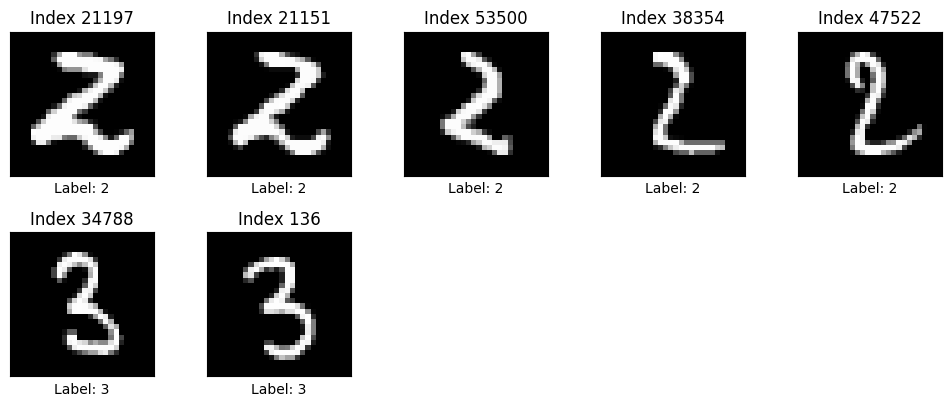

In [20]:

indices = list(path1['index'])
final_ind = list([path1['next_index'].iloc[-1]])


# 4. Plot them
plt.figure(figsize=(10, 10))
for i, idx in enumerate(indices):
    plt.subplot(5, 5, i + 1)
    x = X.iloc[idx].values.reshape(28, 28)  # reshape to 28x28
    plt.imshow(x, cmap="gray")  # grayscale for MNIST
    plt.title(f"Index {idx}")
    plt.xticks([])   # remove tick labels, keep axis
    plt.yticks([])
    plt.xlabel(f"Label: {y.iloc[idx]}")

    

plt.tight_layout()
plt.show()



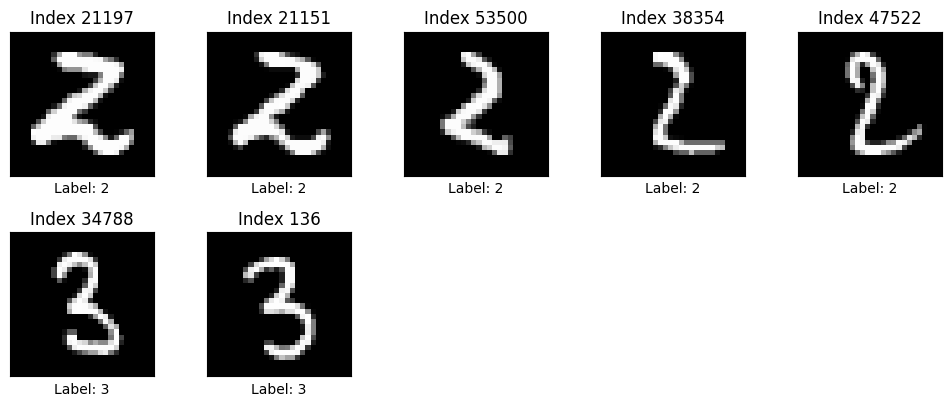

In [21]:

indices = list(path2['index'])
final_ind = list([path2['next_index'].iloc[-1]])


# 4. Plot them
plt.figure(figsize=(10, 10))
for i, idx in enumerate(indices):
    plt.subplot(5, 5, i + 1)
    x = X.iloc[idx].values.reshape(28, 28)  # reshape to 28x28
    plt.imshow(x, cmap="gray")  # grayscale for MNIST
    plt.title(f"Index {idx}")

    plt.xticks([])   # remove tick labels, keep axis
    plt.yticks([])
    plt.xlabel(f"Label: {y.iloc[idx]}")

plt.tight_layout()
plt.show()



In [22]:


def get_cf_indices(df):
    """
    Adds new_index and new_next_index columns when start_label != end_label.
    """
    cf_df = pd.DataFrame()
    
    # initialize empty columns
    
    start_label = y[df['index']]
    end_label = y[df['end_index']]
    # condition: start_label != end_label
    mask = start_label != end_label
    
    # fill new columns only where mismatch occurs
    cf_df["index"] = df.loc[mask, "index"]
    cf_df["next_index"] = df.loc[mask, "next_index"]
    
    return cf_df


In [23]:
if path_type == 'raw':
    paths = raw_paths
elif path_type == 'pca':
    paths = pca_paths
else:
    raise ValueError("path_type must be 'raw' or 'pca'")

if path_type == 'direct':

    direct_paths = pd.DataFrame()
    # Split path_id into start_id and end_id
    direct_paths[['index', 'next_index']] = paths['path_id'].str.split('_', expand=True).astype(int)
    paths = direct_paths
elif path_type == 'local':
    paths = get_cf_indices(paths)
    



print(len(paths))
paths = paths[paths['index'].isin(X_train.index)]
print(len(paths))
paths = paths[paths['next_index'].isin(X_train.index)]
print(len(paths))

paths = paths.sample(n=n_train, random_state=42)
print(len(paths))

735810
593141
480825
5000


In [24]:
X_train_sample = np.array(X_train.loc[paths['index']])
y_train_sample = np.array(y_train.loc[paths['index']])

cf_X_sample = np.array(X_train.loc[paths['next_index']])
cf_y_sample = np.array(y_train.loc[paths['next_index']])

In [25]:

def compile_mnist(X,y,cf_X,cf_y):

    magnitude = np.ones(len(cf_X))
    magnitude = np.expand_dims(magnitude, axis=1)
    
    print(f'Returning {len(X)} samples with {len(cf_y)} counterfactuals')
    
    return {'X':np.array(X),
            'Y':list(y),
            'K':{
                'vector':np.expand_dims(cf_X,axis=1),
                 'label':np.expand_dims(cf_y,axis=1),
                 'magnitude':np.expand_dims(magnitude,axis=1), 
                 }}


# Stripping html from unprocessed text, just to clean it up
print('\ntrain_Data')
cf_train={'original': compile_mnist(X_train_sample,y_train_sample,cf_X_sample,cf_y_sample)} # X,y,text,cf_X,cf_text

print('\ndev_Data')
cf_dev={'original': compile_mnist(X_dev,y_dev,np.zeros_like(X_dev),np.zeros_like(y_dev))} # X,y,text,cf_X,cf_text

print('\ntest_Data')
cf_test={'original': compile_mnist(X_test,y_test,np.zeros_like(X_test),np.zeros_like(y_test))} # X,y,text,cf_X,cf_text




train_Data
Returning 5000 samples with 5000 counterfactuals

dev_Data
Returning 12000 samples with 12000 counterfactuals

test_Data
Returning 10000 samples with 10000 counterfactuals


In [26]:
"""
########################################################################################################################
Save embeddings
########################################################################################################################
"""

pickle_data = {'train':cf_train,'test':cf_test,'dev':cf_dev, 'n_classes': 10}

embedding_path = f'data/integer_len{n_train}__connected_{str(connected_paths)}__path_{path_type}__length_{path_length}.pkl'
print(f"Saving to {embedding_path}")
with open(embedding_path, 'wb') as file:
    pkl.dump(pickle_data, file)

Saving to data/integer_len5000__connected_False__path_pca__length_local.pkl
